## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from sklearn.metrics import mean_absolute_error, mean_squared_error

## Load Dataset

In [ ]:
amzn = pd.read_csv("AMZN.csv", parse_dates=["Date"])
csco = pd.read_csv("CSCO.csv", parse_dates=["Date"])

print("AMZN shape:", amzn.shape)
print("Date range:", amzn["Date"].min().date(), "→", amzn["Date"].max().date())
amzn.head()

AMZN shape: (5758, 7)
Date range: 1997-05-15 → 2020-04-01


,Date,Open,High,Low,Close,Adj Close,Volume
0,1997-05-15,2.437500,2.500000,1.927083,1.958333,1.958333,72156000
1,1997-05-16,1.968750,1.979167,1.708333,1.729167,1.729167,14700000
2,1997-05-19,1.760417,1.770833,1.625000,1.708333,1.708333,6106800
3,1997-05-20,1.729167,1.750000,1.635417,1.635417,1.635417,5467200
4,1997-05-21,1.635417,1.645833,1.375000,1.427083,1.427083,18853200


In [ ]:
print("CSCO shape:", csco.shape)
print("Date range:", csco["Date"].min().date(), "→", csco["Date"].max().date())
csco.head()

CSCO shape: (7589, 7)
Date range: 1990-02-16 → 2020-04-01


,Date,Open,High,Low,Close,Adj Close,Volume
0,1990-02-16,0.0,0.079861,0.073785,0.077257,0.059806,940636800
1,1990-02-20,0.0,0.079861,0.074653,0.079861,0.061822,151862400
2,1990-02-21,0.0,0.078993,0.075521,0.078125,0.060478,70531200
3,1990-02-22,0.0,0.081597,0.078993,0.078993,0.061150,45216000
4,1990-02-23,0.0,0.079861,0.078125,0.078559,0.060814,44697600


## Data Understanding

### Dataset Info

In [ ]:
amzn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5758 entries, 0 to 5757
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       5758 non-null   datetime64[ns]
 1   Open       5758 non-null   float64       
 2   High       5758 non-null   float64       
 3   Low        5758 non-null   float64       
 4   Close      5758 non-null   float64       
 5   Adj Close  5758 non-null   float64       
 6   Volume     5758 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 315.0 KB


- Dataset AMZN terdiri dari 5758 baris dan 7 kolom.
- Tidak ada kesalahan tipe data

In [ ]:
csco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7589 entries, 0 to 7588
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       7589 non-null   datetime64[ns]
 1   Open       7589 non-null   float64       
 2   High       7589 non-null   float64       
 3   Low        7589 non-null   float64       
 4   Close      7589 non-null   float64       
 5   Adj Close  7589 non-null   float64       
 6   Volume     7589 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 415.2 KB


- Dataset CSCO terdiri dari 5758 baris dan 7 kolom.
- Tidak ada kesalahan tipe data

### Statistics Summary & Missing Values

In [ ]:
def summary(df):
    data = pd.DataFrame(df.dtypes, columns=["dtypes"])
    data["missing#"] = df.isna().sum().values
    data["missing%"] = (df.isna().sum().values * 100) / len(df)
    data["uniques"] = df.nunique().values
    data["count"] = df.count().values

    num_df = df.select_dtypes(include="number")
    desc = num_df.describe().T
    for col in ["min","25%","50%","75%","max","mean","std"]:
        data[col] = desc[col] if col in desc.columns else np.nan

    skew_vals = pd.Series(num_df.skew().values, index=num_df.columns)
    data["skew"] = data.index.map(lambda x: skew_vals.get(x,np.nan))

    return data

In [ ]:
summary(amzn)

,dtypes,missing#,missing%,uniques,count,min,25%,50%,75%,max,mean,std,skew
Date,datetime64[ns],0,0.0,5758,5758,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Open,float64,0,0.0,5070,5758,1.406250,3.746000e+01,8.196500e+01,3.352675e+02,2.173070e+03,3.404582e+02,5.233654e+02,1.969648
High,float64,0,0.0,5014,5758,1.447917,3.833500e+01,8.352000e+01,3.375375e+02,2.185950e+03,3.441564e+02,5.281386e+02,1.970595
Low,float64,0,0.0,5019,5758,1.312500,3.681250e+01,7.987500e+01,3.317275e+02,2.161120e+03,3.363444e+02,5.177270e+02,1.968616
Close,float64,0,0.0,5148,5758,1.395833,3.756250e+01,8.160000e+01,3.342900e+02,2.170220e+03,3.404176e+02,5.231402e+02,1.969053
Adj Close,float64,0,0.0,5148,5758,1.395833,3.756250e+01,8.160000e+01,3.342900e+02,2.170220e+03,3.404176e+02,5.231402e+02,1.969053
Volume,int64,0,0.0,5615,5758,487200.000000,3.685525e+06,5.692450e+06,8.594350e+06,1.043292e+08,7.556094e+06,7.325904e+06,4.439800


- Seluruh variabel tidak memiliki missing value (0%).
- Harga saham Amazon menunjukkan rentang nilai yang sangat besar, dimana harga penutupan (Close) berkisar antara 1,40 hingga 2.170,22 USD dengan rata-rata 340,42 USD dan standar deviasi 523,14 USD.
- Nilai skewness pada seluruh variabel harga mendekati 2, yang menunjukkan distribusi miring ke kanan (positively skewed). Hal ini mengindikasikan adanya tren kenaikan harga saham yang sangat signifikan selama periode pengamatan. Selain itu, Volume memiliki skewness sebesar 4,44 yang menunjukkan distribusi transaksi yang sangat tidak merata dengan beberapa periode volume perdagangan yang sangat tinggi.

In [ ]:
summary(csco)

,dtypes,missing#,missing%,uniques,count,min,25%,50%,75%,max,mean,std,skew
Date,datetime64[ns],0,0.0,7589,7589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Open,float64,0,0.0,3784,7589,0.000000,8.444445e+00,1.970000e+01,2.713000e+01,8.143750e+01,2.040453e+01,1.491539e+01,0.800020
High,float64,0,0.0,3784,7589,0.072917,8.583333e+00,1.993750e+01,2.741000e+01,8.200000e+01,2.068205e+01,1.513319e+01,0.818874
Low,float64,0,0.0,3777,7589,0.068576,8.326389e+00,1.944000e+01,2.683000e+01,7.906250e+01,2.011629e+01,1.467615e+01,0.774088
Close,float64,0,0.0,3943,7589,0.071181,8.479167e+00,1.968000e+01,2.712000e+01,8.006250e+01,2.039954e+01,1.490659e+01,0.797980
Adj Close,float64,0,0.0,5022,7589,0.055102,6.563846e+00,1.531199e+01,2.184508e+01,6.197754e+01,1.694520e+01,1.325330e+01,0.944522
Volume,int64,0,0.0,7518,7589,806400.000000,3.245060e+07,4.898850e+07,6.822650e+07,9.406368e+08,5.680188e+07,4.168727e+07,5.068231


- Seluruh variabel tidak memiliki missing value (0%).
- Harga penutupan (Close) berada pada rentang 0,07 hingga 80,06 USD dengan rata-rata 20,40 USD dan standar deviasi 14,91 USD.
- Nilai skewness variabel harga berada pada kisaran 0,77–0,94 yang menunjukkan distribusi sedikit miring ke kanan, namun lebih stabil dibandingkan AMZN. Variabel Volume memiliki skewness sebesar 5,07 yang menunjukkan adanya beberapa periode dengan aktivitas perdagangan yang sangat tinggi dibandingkan mayoritas periode lainnya.

### Check Duplicate

In [ ]:
print("AMZN Duplicate :", amzn.duplicated().sum())
print("CSCO Duplicate :", csco.duplicated().sum())

AMZN Duplicate : 0
CSCO Duplicate : 0


Tidak ada duplikat pada kedua dataset

## EDA

### Feature Distribution


AMZN


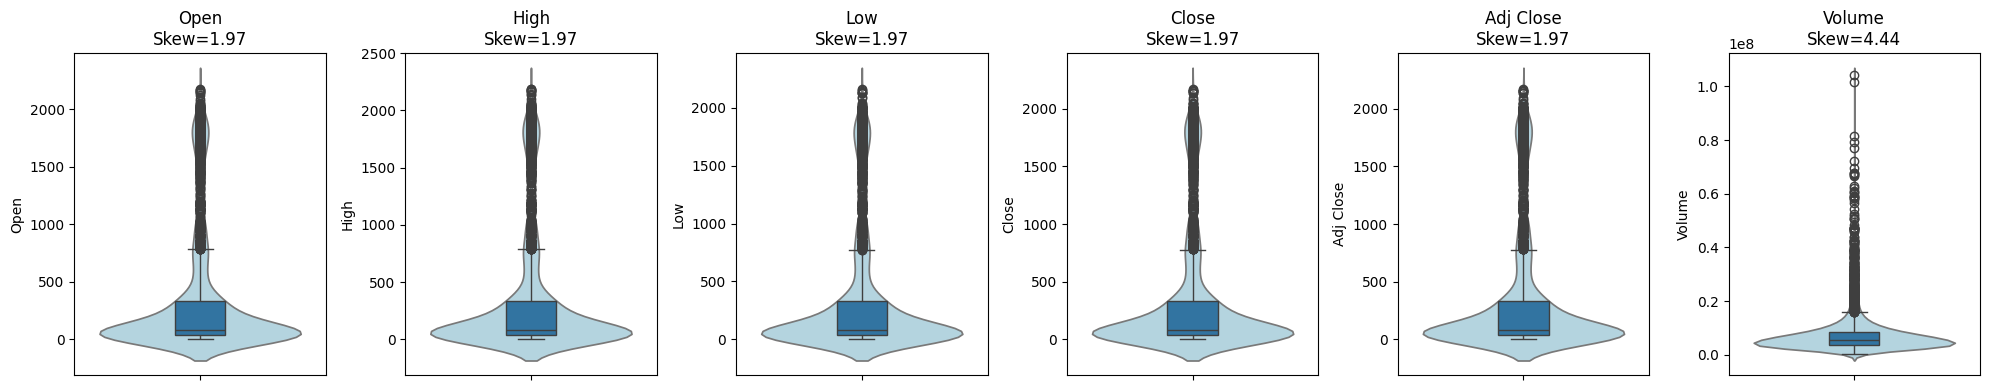


CSCO


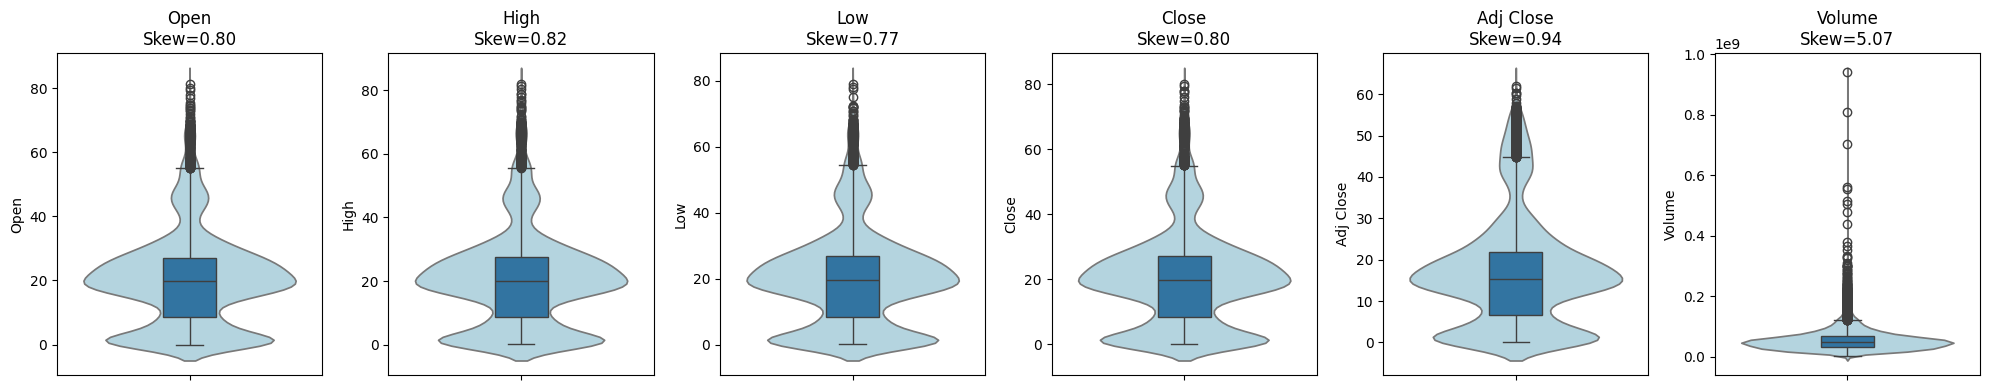

In [ ]:
num_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]

for name, df in [("AMZN",amzn),("CSCO",csco)]:
    print(f"\n{name}")
    fig, axes = plt.subplots(1, len(num_cols), figsize=(20,4))

    for ax,col in zip(axes,num_cols):
        sns.violinplot(y=df[col], inner=None, color="lightblue", ax=ax)
        sns.boxplot(y=df[col], width=0.2, ax=ax)
        ax.set_title(f"{col}\nSkew={df[col].skew():.2f}")

    plt.tight_layout()
    plt.show()

Terdapat sejumlah besar nilai yang teridentifikasi sebagai outlier pada boxplot, terutama pada AMZN. Namun karena data merupakan time series harga saham yang mengalami tren pertumbuhan jangka panjang, nilai-nilai tersebut dianggap sebagai variasi alami data.

### Correlation

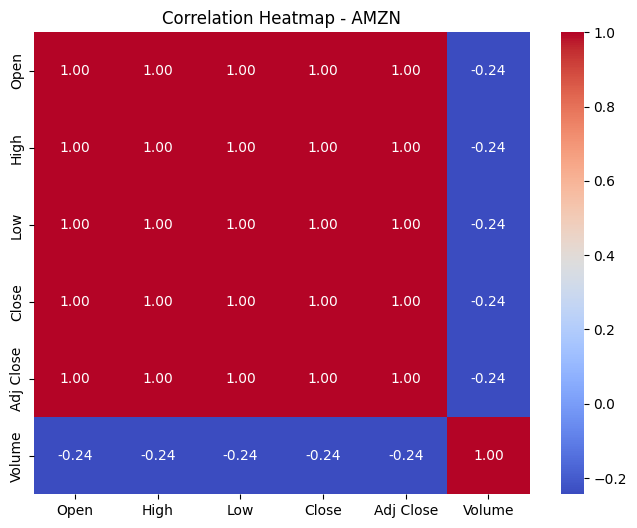

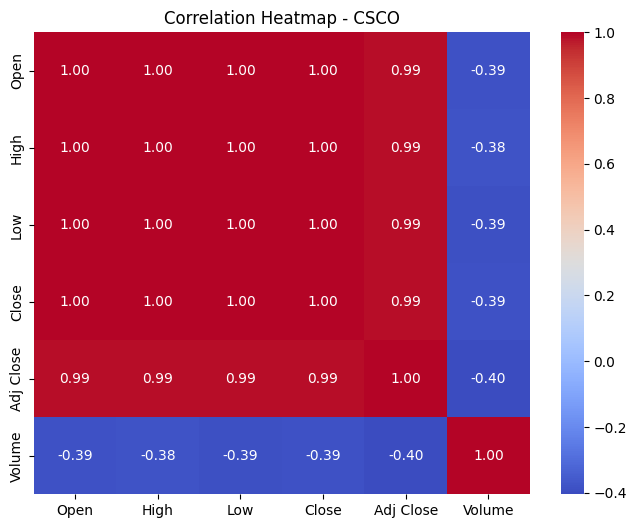

In [ ]:
for name, df in [("AMZN",amzn),("CSCO",csco)]:
    corr = (df.select_dtypes(include="number").corr())

    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title(f"Correlation Heatmap - {name}")
    plt.show()

Berdasarkan heatmap korelasi, variabel Open, High, Low, Close, dan Adj Close memiliki korelasi yang sangat tinggi (mendekati 1). Hal ini menunjukkan bahwa informasi yang terkandung pada variabel harga relatif serupa. Karena harga pembukaan, penutupan, tertinggi, dan terendah pada saham memang sangat berhubungan. Oleh karena itu penggunaan variabel Close sebagai target prediksi dianggap representatif dan juga sesuai dengan instruksi soal yang hanya menggunakan kolom Date dan Close.

### Time Series Plot

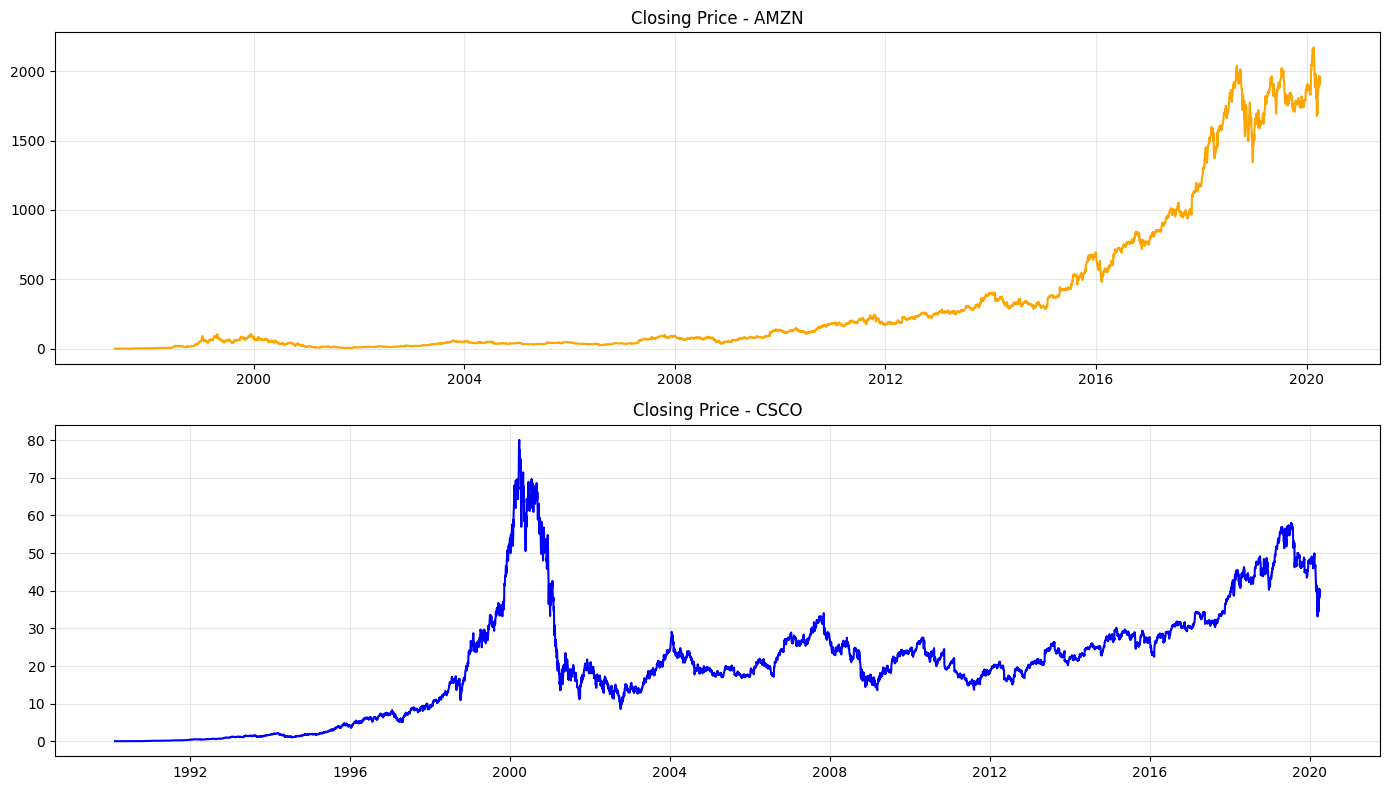

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14,8))

for ax,df,name,color in zip(axes, [amzn,csco], ["AMZN","CSCO"], ["orange","blue"]):
    ax.plot(df["Date"], df["Close"], color=color)
    ax.set_title(f"Closing Price - {name}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Time Series Plot AMZN   

Grafik harga penutupan AMZN menunjukkan tren meningkat yang sangat kuat (upward trend). Pada periode awal (1997–2007), harga saham relatif rendah dan perubahannya terlihat kecil. Setelah tahun 2008, pertumbuhan harga mulai meningkat secara signifikan hingga mencapai lebih dari 2.000 USD. Selain itu, volatilitas harga juga meningkat seiring waktu, yang menunjukkan bahwa data bersifat non-stasioner dan memiliki tren jangka panjang yang kuat.

Time Series Plot CSCO   

Grafik harga penutupan CSCO menunjukkan pola yang berbeda dibandingkan AMZN. Terjadi kenaikan harga yang sangat tajam hingga mencapai puncak sekitar tahun 2000 (kemungkinan berkaitan dengan periode dot-com bubble yang menyebabkan kenaikan signifikan pada saham sektor teknologi), kemudian diikuti penurunan drastis pada tahun 2001–2002. Setelah itu harga saham bergerak fluktuatif dengan kecenderungan meningkat secara bertahap hingga tahun 2020. Pola ini menunjukkan adanya perubahan tren dan volatilitas yang cukup tinggi pada beberapa periode.

## Preprocessing

In [ ]:
amzn = amzn[["Date","Close"]]
csco = csco[["Date","Close"]]

In [ ]:
amzn = amzn.set_index("Date").sort_index()
csco = csco.set_index("Date").sort_index()

### Split Train Test

In [ ]:
def split_train_test(df):
    last_date = df.index.max()
    test_start = last_date - pd.DateOffset(years=1)
    train = df[df.index < test_start]
    test = df[df.index >= test_start]
    return train,test

amzn_train, amzn_test = split_train_test(amzn)
csco_train, csco_test = split_train_test(csco)

### Scaling

In [ ]:
scaler_amzn = MinMaxScaler()
scaler_csco = MinMaxScaler()

amzn_train_scaled = scaler_amzn.fit_transform(amzn_train)
amzn_test_scaled = scaler_amzn.transform(amzn_test)

csco_train_scaled = scaler_csco.fit_transform(csco_train)
csco_test_scaled = scaler_csco.transform(csco_test)

print("AMZN train scaled shape:", amzn_train_scaled.shape)
print("CSCO train scaled shape:", csco_train_scaled.shape)

AMZN train scaled shape: (5504, 1)
CSCO train scaled shape: (7335, 1)


### Sliding Window

- Window Size = 5 (Senin - Jumat)
- Horizon = 1 (prediksi 1 hari ke depan / Senin berikutnya)

In [ ]:
WINDOW_SIZE = 5
HORIZON     = 1

def create_sequences(data, window_size=WINDOW_SIZE, horizon=HORIZON):
    x, y = [], []

    for i in range(len(data) - window_size - horizon + 1):
        x.append(data[i : i + window_size, 0])
        y.append(data[i + window_size : i + window_size + horizon, 0])

    x = np.array(x).reshape(-1, window_size, 1)
    y = np.array(y)

    return x, y

x_amzn_all, y_amzn_all = create_sequences(amzn_train_scaled)
x_amzn_test, y_amzn_test = create_sequences(amzn_test_scaled)
x_csco_all, y_csco_all = create_sequences(csco_train_scaled)
x_csco_test, y_csco_test = create_sequences(csco_test_scaled)

print("AMZN train sequences — x:", x_amzn_all.shape, "| y:", y_amzn_all.shape)
print("AMZN test sequences — x:", x_amzn_test.shape, "| y:", y_amzn_test.shape)
print("CSCO train sequences — x:", x_csco_all.shape, "| y:", y_csco_all.shape)
print("CSCO test sequences — x:", x_csco_test.shape, "| y:", y_csco_test.shape)

AMZN train sequences — x: (5499, 5, 1) | y: (5499, 1)
AMZN test sequences — x: (249, 5, 1) | y: (249, 1)
CSCO train sequences — x: (7330, 5, 1) | y: (7330, 1)
CSCO test sequences — x: (249, 5, 1) | y: (249, 1)


### Split Train-Validation

- Train (90%)
- Validation (10%)

In [ ]:
split_idx_amzn = int(len(x_amzn_all) * 0.9)

x_amzn_train = x_amzn_all[:split_idx_amzn]
y_amzn_train = y_amzn_all[:split_idx_amzn]

x_amzn_val = x_amzn_all[split_idx_amzn:]
y_amzn_val = y_amzn_all[split_idx_amzn:]

print(f"AMZN — Train x: {x_amzn_train.shape} | Train y: {y_amzn_train.shape}")
print(f"AMZN — Val x: {x_amzn_val.shape} | Val y: {y_amzn_val.shape}")

AMZN — Train x: (4949, 5, 1) | Train y: (4949, 1)
AMZN — Val x: (550, 5, 1) | Val y: (550, 1)


In [ ]:
split_idx_csco = int(len(x_csco_all)*0.9)

x_csco_train = x_csco_all[:split_idx_csco]
y_csco_train = y_csco_all[:split_idx_csco]

x_csco_val = x_csco_all[split_idx_csco:]
y_csco_val = y_csco_all[split_idx_csco:]

print(f"CSCO — Train x: {x_csco_train.shape} | Train y: {y_csco_train.shape}")
print(f"CSCO — Val x: {x_csco_val.shape} | Val y: {y_csco_val.shape}")

CSCO — Train x: (6597, 5, 1) | Train y: (6597, 1)
CSCO — Val x: (733, 5, 1) | Val y: (733, 1)


## LSTM Modelling

### Baseline Model

In [ ]:
baseline_amzn = Sequential([LSTM(units=50, activation='relu', input_shape=(WINDOW_SIZE, 1)),
                            Dense(units=1)], name="Baseline_AMZN")

baseline_amzn.compile(optimizer='adam', loss='mse')
baseline_amzn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Baseline_AMZN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_csco = Sequential([LSTM(units=50, activation='relu', input_shape=(WINDOW_SIZE, 1)),
                            Dense(units=1)], name="Baseline_CSCO")

baseline_csco.compile(optimizer='adam', loss='mse')
baseline_csco.summary()

Model: "Baseline_CSCO"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history_base_amzn = baseline_amzn.fit(
    x_amzn_train, y_amzn_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_amzn_val, y_amzn_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0016 - val_loss: 0.0052
Epoch 2/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.3106e-05 - val_loss: 0.0049
Epoch 3/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.2774e-05 - val_loss: 0.0045
Epoch 4/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2860e-05 - val_loss: 0.0050
Epoch 5/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.2500e-05 - val_loss: 0.0045
Epoch 6/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4273e-05 - val_loss: 0.0028
Epoch 7/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2909e-05 - val_loss: 0.0029
Epoch 8/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3957e-05 - val_loss: 0.0033
Epoch 9/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.2286e-05 - val_loss: 0.0037
Epoch 10/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.3483e-05 - val_loss: 0.0032
Epoch 11/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2568e-05 - val_loss: 0.0020


In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history_base_csco = baseline_csco.fit(
    x_csco_train, y_csco_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_csco_val, y_csco_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0059 - val_loss: 8.4422e-05
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2738e-04 - val_loss: 1.0589e-04
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2291e-04 - val_loss: 2.1834e-04
Epoch 4/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2049e-04 - val_loss: 8.6321e-05
Epoch 5/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2840e-04 - val_loss: 1.0857e-04
Epoch 6/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2284e-04 - val_loss: 1.7289e-04
Epoch 7/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1817e-04 - val_loss: 8.1946e-05
Epoch 8/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1689e-04 - val_loss: 1.2297e-04
Epoch 9/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1490e-04 - val_loss: 7.1589e-05
Epoch 10/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2312e-04 - val_loss: 2.4676e-04
Epoch 11/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

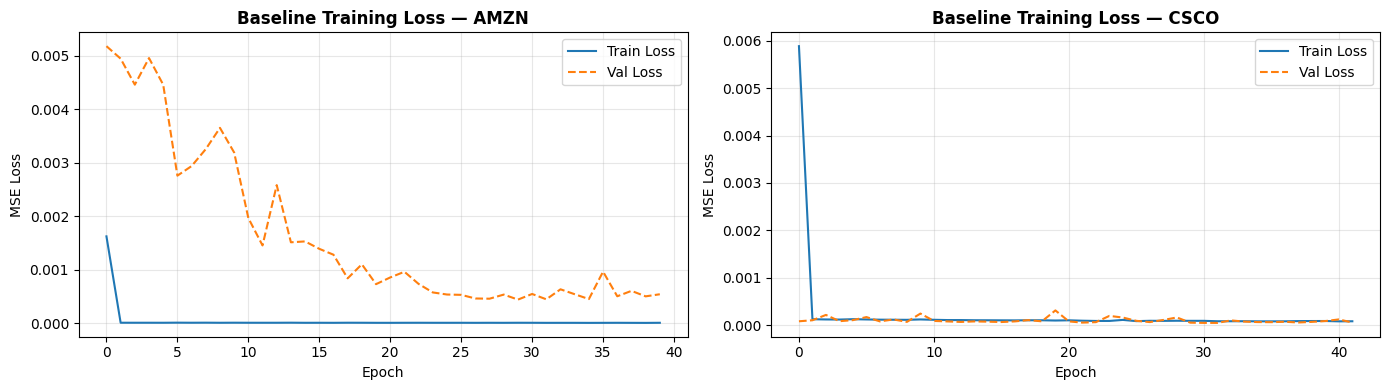

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, history, name in zip(axes,[history_base_amzn, history_base_csco], ["AMZN", "CSCO"]):
    ax.plot(history.history['loss'], label='Train Loss')
    ax.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
    ax.set_title(f'Baseline Training Loss — {name}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Model menghasilkan validation loss yang lebih kecil pada dataset CSCO dibandingkan AMZN. Hal ini mengindikasikan bahwa pola pergerakan harga saham CSCO lebih mudah dipelajari oleh model LSTM dibandingkan AMZN yang memiliki tren pertumbuhan dan volatilitas yang lebih tinggi selama periode pengamatan.

### Modified Model

#### Modified Model AMZN

Sebelum menentukan arsitektur final, dilakukan serangkaian eksperimen:

**AMZN:**
- v1 (Stacked LSTM 128→64, Dropout 0.2): overfitting, val_loss naik
  terus dari epoch 1
- v2 (Stacked LSTM 64→32, Dropout 0.3): membaik tapi val_loss masih
  sangat fluktuatif
- v3 (Single LSTM 64, L2 1e-3, Dropout 0.2) → **dipilih sebagai final**
- v4 (Single LSTM 64, L2 1e-3, Dropout 0.3): sedikit lebih buruk dari v3

**Modified Model AMZN**
1. **L2 Regularization (kernel & recurrent, rate=1e-3)**:   
Baseline tidak memiliki regularisasi sama sekali. AMZN memiliki data yang sangat eksponensial dan volatile sehingga sangat rentan overfitting. L2 menghukum bobot yang terlalu besar secara langsung di dalam LSTM, memaksa model untuk belajar representasi yang lebih general.

2. **Dropout (rate=0.2)**:   
Melengkapi L2 sebagai lapisan regularisasi kedua. Dropout menonaktifkan 20% neuron secara acak setiap iterasi sehingga model tidak bergantung pada neuron tertentu dan lebih robust terhadap data baru.

3. **Single LSTM layer (bukan Stacked)**   
Eksperimen dengan Stacked LSTM (v1: 128→64, v2: 64→32) menghasilkan overfitting parah karena terlalu kompleks untuk window size = 5. Single layer lebih sesuai karena pola yang perlu ditangkap hanya dari 5 hari perdagangan.

4. **Units ditambah (50→64, tetap single layer)**:   
Jumlah unit LSTM ditingkatkan dari 50 menjadi 64 untuk meningkatkan kapasitas model dalam menangkap pola temporal pada data AMZN. Karena tetap menggunakan single LSTM layer, kompleksitas model masih relatif terkendali dibanding stacked LSTM yang sebelumnya menunjukkan overfitting.

5. **Learning rate dikecilkan (default→0.001 eksplisit)**:   
Memberikan kontrol lebih terhadap kecepatan konvergensi.

6. **ModelCheckpoint menggantikan EarlyStopping**:   
EarlyStopping menghentikan training berdasarkan val_loss yang noisy dan bisa berhenti terlalu cepat. ModelCheckpoint membiarkan model training penuh (100 epoch) lalu mengambil bobot dari epoch dengan val_loss terkecil (keputusan yang lebih objektif).

In [ ]:
tf.keras.backend.clear_session()

modified_amzn = Sequential([LSTM(units=64, activation='relu', kernel_regularizer=l2(1e-3),
                                 recurrent_regularizer=l2(1e-3), input_shape=(WINDOW_SIZE, 1)),
                            Dropout(0.2),
                            Dense(units=1)], name="Modified_AMZN")

modified_amzn.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
modified_amzn.summary()

Model: "Modified_AMZN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
checkpoint_amzn = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_modified_amzn.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=0
)

history_mod_amzn = modified_amzn.fit(
    x_amzn_train, y_amzn_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_amzn_val, y_amzn_val),
    callbacks=[checkpoint_amzn],
    verbose=1
)

modified_amzn.load_weights('best_modified_amzn.weights.h5')
print(f"Best epoch: {int(np.argmin(history_mod_amzn.history['val_loss'])) + 1}")
print(f"Best val_loss: {min(history_mod_amzn.history['val_loss']):.6f}")

Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0342 - val_loss: 0.1148
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0054 - val_loss: 0.0645
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0018 - val_loss: 0.0414
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 0.0318
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.2996e-04 - val_loss: 0.0148
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.5846e-04 - val_loss: 0.0142
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.8439e-04 - val_loss: 0.0071
Epoch 8/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.2770e-04 - val_loss: 0.0078
Epoch 9/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.1917e-04 - val_loss: 0.0053
Epoch 10/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.6741e-04 - val_loss: 0.0065
Epoch 11/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.4961e-04 - val_loss: 0.0042
Epoch 12/100
78/78 ━━━━━━━━━━━━━━━

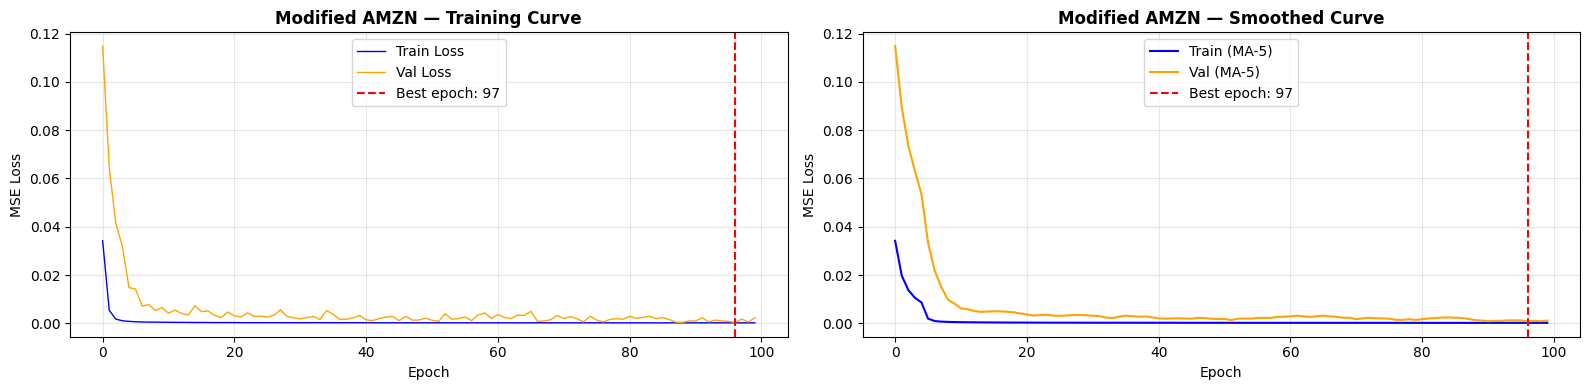

In [ ]:
def smooth(values, window=5):
    return pd.Series(values).rolling(window, min_periods=1).mean().values

def plot_training_curve(history, title):
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    best_ep = int(np.argmin(val_loss))

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    axes[0].plot(train_loss, color='blue', lw=1.0, label='Train Loss')
    axes[0].plot(val_loss, color='orange', lw=1.0, label='Val Loss')
    axes[0].axvline(x=best_ep, color='red', ls='--', label=f'Best epoch: {best_ep + 1}')
    axes[0].set_title(f'{title} — Training Curve', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(smooth(train_loss), color='blue', lw=1.5, label='Train (MA-5)')
    axes[1].plot(smooth(val_loss), color='orange', lw=1.5, label='Val (MA-5)')
    axes[1].axvline(x=best_ep, color='red', ls='--', label=f'Best epoch: {best_ep + 1}')
    axes[1].set_title(f'{title} — Smoothed Curve', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_curve(history_mod_amzn, "Modified AMZN")

Modified AMZN menggunakan kombinasi LSTM 64 unit, L2 Regularization, dan Dropout 0.2 untuk mengurangi risiko overfitting dan meningkatkan kemampuan generalisasi model. Hasil training menunjukkan validation loss yang lebih rendah dan lebih stabil dibandingkan baseline. Hal ini mengindikasikan bahwa penambahan regularisasi membantu model mempelajari pola data AMZN yang volatil dengan lebih baik pada data validasi. Namun, efektivitas akhir model tetap perlu dikonfirmasi melalui evaluasi pada test set.

#### Modified Model CSCO

Sebelum menentukan arsitektur final, dilakukan serangkaian eksperimen:

**CSCO:**
- v1 (Stacked LSTM 128→64, Dense 16): val_loss lebih tinggi dari baseline
- v2 (Single LSTM 64, Dropout 0.1, Dense 8): mendekati baseline
- v3 (LSTM 128, Dropout 0.1, Dense 8, batch 16) → **dipilih sebagai final**

**Modified Model CSCO**
1. **Arsitektur berbeda dari AMZN — tanpa L2 Regularization**   
CSCO memiliki karakteristik yang berbeda dari AMZN: harga lebih stabil (~10–80), tidak eksponensial, dan sudah konvergen dengan baik sejak baseline. L2 tidak diperlukan karena masalah utama bukan overfitting yang parah seperti AMZN, melainkan kapasitas model yang belum optimal.

2. **Units dinaikkan 50→128**   
Berbeda dari AMZN yang perlu disederhanakan, CSCO justru membutuhkan kapasitas lebih untuk menangkap pola yang mencakup periode panjang (1990–2019) termasuk dot-com
bubble (2000) dan recovery bertahap setelahnya.

3. **Dropout ringan (rate=0.1)**  
Regularisasi minimal tetap diperlukan untuk mencegah model bergantung pada neuron tertentu, namun tidak terlalu agresif agar kapasitas model yang lebih besar bisa dimanfaatkan secara optimal.

4. **Dense(8, relu) sebagai hidden layer**   
Menambah satu lapisan transformasi non-linear kecil sebelum output, memberi model kemampuan lebih untuk memetakan representasi LSTM ke prediksi akhir.

5. **Learning rate dikecilkan (0.001→0.0005)**   
Learning rate yang lebih kecil menghasilkan konvergensi yang lebih halus dan stabil untuk data CSCO.

6. **Batch size kecil (16)**  
Batch kecil menghasilkan update gradien lebih sering per epoch, membantu model menemukan minimum yang lebih baik pada data CSCO yang memiliki pola lebih variatif (7589 baris vs AMZN 5758 baris).

7. **ModelCheckpoint (sama seperti AMZN)**   
Konsisten menggunakan pendekatan yang sama untuk memastikan bobot terbaik tersimpan tanpa mengganggu proses training.


In [ ]:
tf.keras.backend.clear_session()

modified_csco = Sequential([LSTM(units=128, activation='relu', input_shape=(WINDOW_SIZE, 1)),
                            Dropout(0.1),
                            Dense(units=8, activation='relu'),
                            Dense(units=1)], name="Modified_CSCO")

modified_csco.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')
modified_csco.summary()

Model: "Modified_CSCO"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         1,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,601 (264.07 KB)

 Trainable params: 67,601 (264.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
checkpoint_csco = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_modified_csco.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=0
)

history_mod_csco = modified_csco.fit(
    x_csco_train, y_csco_train,
    epochs=100,
    batch_size=16,
    validation_data=(x_csco_val, y_csco_val),
    callbacks=[checkpoint_csco],
    verbose=1
)

print(f"Best epoch: {int(np.argmin(history_mod_csco.history['val_loss'])) + 1}")
print(f"Best val_loss: {min(history_mod_csco.history['val_loss']):.6f}")

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0059 - val_loss: 2.9398e-04
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.8723e-04 - val_loss: 1.2444e-04
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.5231e-04 - val_loss: 2.4220e-04
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.1537e-04 - val_loss: 1.0504e-04
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.9855e-04 - val_loss: 5.5173e-04
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.8343e-04 - val_loss: 9.1622e-05
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.6983e-04 - val_loss: 3.1940e-04
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.5822e-04 - val_loss: 3.0220e-04
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.7514e-04 - val_loss: 1.7833e-04
Epoch 10/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.3298e-04 - val_loss: 1.8335e-04
Epoch 11/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

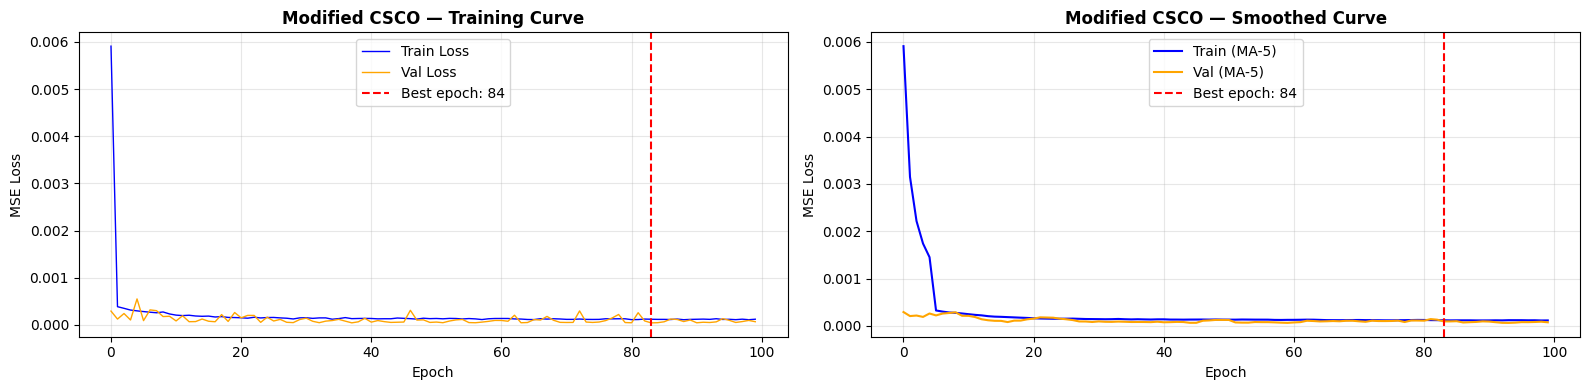

In [ ]:
plot_training_curve(history_mod_csco, "Modified CSCO")

Modified CSCO menunjukkan proses pembelajaran yang stabil dengan train loss dan validation loss yang sama-sama menurun tanpa indikasi overfitting yang signifikan. Peningkatan jumlah unit LSTM menjadi 128, penambahan Dense hidden layer, serta penggunaan learning rate yang lebih kecil memungkinkan model mempelajari pola historis CSCO dengan lebih detail. Validation loss menunjukkan bahwa konfigurasi ini mampu menghasilkan performa yang sangat baik pada data validasi. Namun, efektivitas akhir model tetap perlu dikonfirmasi melalui evaluasi pada test set.

### Baseline VS Modified

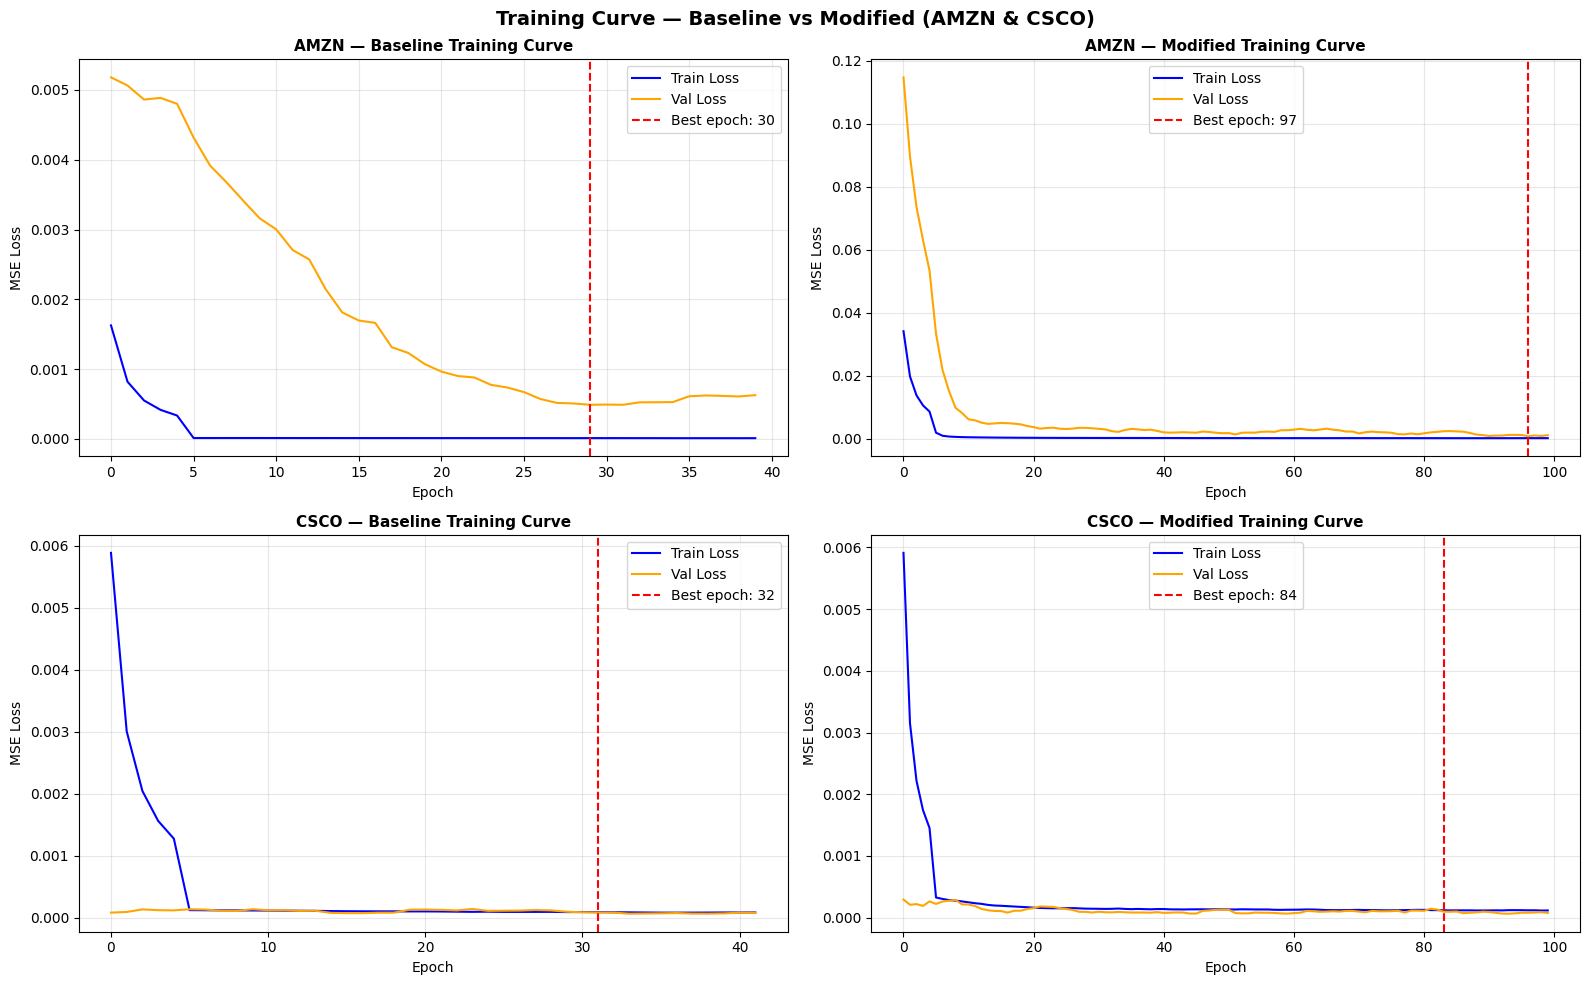


Best Val Loss:
AMZN Baseline : 0.000445
AMZN Modified : 0.000374
CSCO Baseline : 0.000050
CSCO Modified : 0.000044


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (hist_base, hist_mod, name) in enumerate(zip(
        [history_base_amzn, history_base_csco],
        [history_mod_amzn,  history_mod_csco],
        ["AMZN", "CSCO"])):

    axes[row, 0].plot(smooth(hist_base.history['loss']), color='blue', lw=1.5, label='Train Loss')
    axes[row, 0].plot(smooth(hist_base.history['val_loss']), color='orange', lw=1.5, label='Val Loss')
    best_base = int(np.argmin(hist_base.history['val_loss']))

    axes[row, 0].axvline(x=best_base, color='red', ls='--', label=f'Best epoch: {best_base+1}')
    axes[row, 0].set_title(f'{name} — Baseline Training Curve', fontsize=11, fontweight='bold')
    axes[row, 0].set_xlabel('Epoch')
    axes[row, 0].set_ylabel('MSE Loss')
    axes[row, 0].legend()
    axes[row, 0].grid(alpha=0.3)

    axes[row, 1].plot(smooth(hist_mod.history['loss']), color='blue', lw=1.5, label='Train Loss')
    axes[row, 1].plot(smooth(hist_mod.history['val_loss']), color='orange', lw=1.5, label='Val Loss')
    best_mod = int(np.argmin(hist_mod.history['val_loss']))

    axes[row, 1].axvline(x=best_mod, color='red', ls='--', label=f'Best epoch: {best_mod+1}')
    axes[row, 1].set_title(f'{name} — Modified Training Curve', fontsize=11, fontweight='bold')
    axes[row, 1].set_xlabel('Epoch')
    axes[row, 1].set_ylabel('MSE Loss')
    axes[row, 1].legend()
    axes[row, 1].grid(alpha=0.3)

plt.suptitle('Training Curve — Baseline vs Modified (AMZN & CSCO)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nBest Val Loss:")
print(f"AMZN Baseline : {min(history_base_amzn.history['val_loss']):.6f}")
print(f"AMZN Modified : {min(history_mod_amzn.history['val_loss']):.6f}")
print(f"CSCO Baseline : {min(history_base_csco.history['val_loss']):.6f}")
print(f"CSCO Modified : {min(history_mod_csco.history['val_loss']):.6f}")

**AMZN**   
Pada saham AMZN, model baseline menunjukkan indikasi overfitting yang ditandai dengan train loss yang sangat cepat mendekati nol sementara validation loss masih relatif tinggi. Setelah dilakukan modifikasi berupa L2 regularization, dropout, dan penggunaan ModelCheckpoint, model mampu menghasilkan validation loss yang lebih rendah dan stabil. Hal ini menunjukkan bahwa modifikasi berhasil mengurangi overfitting dan meningkatkan performa model pada data validasi.

**CSCO**   
Pada saham CSCO, model baseline sudah menunjukkan validation loss yang rendah dan stabil. Setelah dilakukan modifikasi berupa peningkatan jumlah unit LSTM, penambahan hidden layer Dense, penurunan learning rate, dan penggunaan batch size yang lebih kecil, model menghasilkan validation loss yang lebih rendah dibandingkan baseline. Hal ini menunjukkan bahwa model modifikasi mampu menyesuaikan diri dengan data validasi secara lebih baik.

Modifikasi arsitektur pada **kedua dataset berhasil menghasilkan validation loss yang lebih rendah dibandingkan baseline**, meskipun melalui pendekatan yang berbeda. Pada AMZN, perbaikan difokuskan pada pengurangan overfitting melalui regularisasi, sedangkan pada CSCO difokuskan pada peningkatan kapasitas model untuk mempelajari pola historis yang lebih kompleks. Namun, validation loss hanya mencerminkan performa pada data validasi, sehingga kualitas akhir model tetap harus ditentukan melalui evaluasi menggunakan RMSE, MAE, dan MAPE pada data test.

## Evaluation

In [ ]:
def evaluate_model(model, x_test, y_test, scaler, model_name):
    y_pred = model.predict(x_test, verbose=0)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    y_pred_inv = scaler.inverse_transform(y_pred)

    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

    return{"Model": model_name, "RMSE": rmse, "MAE": mae, "MAPE (%)": mape}

In [ ]:
amzn_base_result = evaluate_model(baseline_amzn, x_amzn_test, y_amzn_test, scaler_amzn, "Baseline AMZN")
amzn_mod_result = evaluate_model(modified_amzn, x_amzn_test, y_amzn_test, scaler_amzn, "Modified AMZN")

csco_base_result = evaluate_model(baseline_csco, x_csco_test, y_csco_test, scaler_csco, "Baseline CSCO")
csco_mod_result = evaluate_model(modified_csco, x_csco_test, y_csco_test, scaler_csco, "Modified CSCO")

results = pd.DataFrame([amzn_base_result, amzn_mod_result, csco_base_result, csco_mod_result])
results

,Model,RMSE,MAE,MAPE (%)
0,Baseline AMZN,53.022936,36.696999,1.964220
1,Modified AMZN,42.971804,29.945928,1.604975
2,Baseline CSCO,1.074568,0.748247,1.607710
3,Modified CSCO,1.065068,0.739309,1.587669


**AMZN**   
Pada saham AMZN, **model Modified AMZN memberikan performa yang lebih baik dibandingkan model baseline**. Nilai **RMSE** menurun dari **53.02 menjadi 42.97**, **MAE dari 36.70 menjadi 29.95**, dan **MAPE dari 1.96% menjadi 1.60%**. Penurunan ketiga metrik tersebut menunjukkan bahwa modifikasi arsitektur berhasil meningkatkan akurasi prediksi sekaligus mengurangi kesalahan prediksi pada data test.

**CSCO**   
Pada saham CSCO, **model Modified CSCO juga memberikan performa yang sedikit lebih baik dibandingkan model baseline**. Nilai **RMSE menurun dari 1.075 menjadi 1.065**, **MAE dari 0.748 menjadi 0.739**, dan **MAPE dari 1.61% menjadi 1.59%**. Meskipun peningkatannya relatif kecil, hasil ini menunjukkan bahwa modifikasi arsitektur tetap mampu meningkatkan akurasi prediksi pada data test.

 Berdasarkan hasil evaluasi menggunakan RMSE, MAE, dan MAPE, **model modifikasi memberikan performa yang lebih baik dibandingkan model baseline pada kedua dataset**. Pada AMZN, peningkatan yang diperoleh cukup signifikan karena modifikasi berhasil mengurangi overfitting dan meningkatkan kemampuan prediksi. Sementara itu, pada CSCO, peningkatan performa relatif kecil karena model baseline memang sudah memiliki akurasi yang baik. Secara keseluruhan, modifikasi arsitektur yang dilakukan berhasil meningkatkan akurasi prediksi untuk kedua saham, sehingga Modified AMZN dan Modified CSCO dipilih sebagai model terbaik.